In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_curve, auc)
from sklearn.preprocessing import label_binarize

import pickle, os
os.makedirs("data", exist_ok=True)
print("Library is loaded.")


Library is loaded.


## Step 1 — Load Preprocessed Data

In [2]:
train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

feature_cols = [c for c in train_df.columns if c != 'disease_label']
X_train = train_df[feature_cols].values
y_train = train_df['disease_label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['disease_label'].values

# Load full scaled data for cross-validation
full_df  = pd.read_csv("data/cleaned_data.csv")
X_scaled = full_df[feature_cols].values
y = full_df['disease_label'].values

# Load label encoders to get class names
with open('data/label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)
class_names = label_encoders['disease_label'].classes_
n_classes   = len(class_names)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Number of disease classes : {n_classes}")
print(f"Classes : {list(class_names)}")


Train : (438, 13)  |  Test : (110, 13)
Number of disease classes : 18
Classes : ['Blast', 'Blight', 'Boll Rot', 'Downy Mildew', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Curl', 'Leaf Spot', 'Mosaic', 'Powdery Mildew', 'Rust', 'Scab', 'Sheath Rot', 'Smut', 'Stalk Rot', 'White Rust', 'Wilt']


## Step 2 — Train All Classifiers

In [11]:
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results  = {}

def train_eval(clf, name):
    clf.fit(X_train, y_train)
    pred  = clf.predict(X_test)
    proba = clf.predict_proba(X_test)      
    acc   = accuracy_score(y_test, pred)
    cv    = cross_val_score(clf, X_scaled, y, cv=cv_strat).mean()
    results[name] = dict(
        clf        = clf,
        accuracy   = acc,
        cv_accuracy= cv,
        predictions= pred,
        proba      = proba,
        f1         = f1_score(y_test, pred, average='weighted'),
        precision  = precision_score(y_test, pred, average='weighted'),
        recall     = recall_score(y_test, pred, average='weighted'),
    )
    print(f"  [{name}]  Acc={acc:.4f}  CV={cv:.4f}  "
          f"F1={results[name]['f1']:.4f}")

print("Training classifiers...\n")

# KNN — find best K via CV
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
             X_train, y_train, cv=5).mean() for k in range(1, 21)]
best_k = np.argmax(k_scores) + 1
print(f"  KNN best K = {best_k}")
train_eval(KNeighborsClassifier(n_neighbors=best_k), 'KNN')

#  Naive Bayes
train_eval(GaussianNB(), 'Naive Bayes')

# SVM 
train_eval(SVC(kernel='rbf', C=1.0, gamma='scale',
               probability=True, random_state=42), 'SVM')

# MLP
train_eval(MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
    solver='adam', max_iter=500, random_state=42,
    early_stopping=True, validation_fraction=0.1), 'MLP')

# Random Forest 
train_eval(RandomForestClassifier(n_estimators=100, random_state=42),
           'Random Forest')

print("\nAll classifiers trained.")


Training classifiers...

  KNN best K = 18
  [KNN]  Acc=0.5182  CV=0.4488  F1=0.4611
  [Naive Bayes]  Acc=0.5455  CV=0.5457  F1=0.4839
  [SVM]  Acc=0.5545  CV=0.5529  F1=0.4790
  [MLP]  Acc=0.4818  CV=0.5001  F1=0.4319
  [Random Forest]  Acc=0.6000  CV=0.5584  F1=0.5724

All classifiers trained.


## Step 3 — Results & Comparison

In [16]:
algo_names = list(results.keys())
best_name  = max(algo_names, key=lambda a: results[a]['accuracy'])

summary = pd.DataFrame({
    'Test Accuracy' : [f"{results[a]['accuracy']:.4f}"   for a in algo_names],
    'CV Accuracy'   : [f"{results[a]['cv_accuracy']:.4f}" for a in algo_names],
    'F1 Score'      : [f"{results[a]['f1']:.4f}"         for a in algo_names],
    'Precision'     : [f"{results[a]['precision']:.4f}"  for a in algo_names],
    'Recall'        : [f"{results[a]['recall']:.4f}"     for a in algo_names],
    'Best'          : ['Best' if a == best_name else '' for a in algo_names],
}, index=algo_names)
summary.index.name = 'Algorithm'

print("\n  CLASSIFICATION RESULTS")
print(summary.to_string())
print(f"\n  Best Model: {best_name}  (Acc = {results[best_name]['accuracy']:.4f})")

# Save
summary.to_csv("data/classification_results.csv")
print("  Saved: data/classification_results.csv")



  CLASSIFICATION RESULTS
              Test Accuracy CV Accuracy F1 Score Precision  Recall  Best
Algorithm                                                               
KNN                  0.5182      0.4488   0.4611    0.4749  0.5182      
Naive Bayes          0.5455      0.5457   0.4839    0.5156  0.5455      
SVM                  0.5545      0.5529   0.4790    0.4749  0.5545      
MLP                  0.4818      0.5001   0.4319    0.4147  0.4818      
Random Forest        0.6000      0.5584   0.5724    0.5624  0.6000  Best

  Best Model: Random Forest  (Acc = 0.6000)
  Saved: data/classification_results.csv


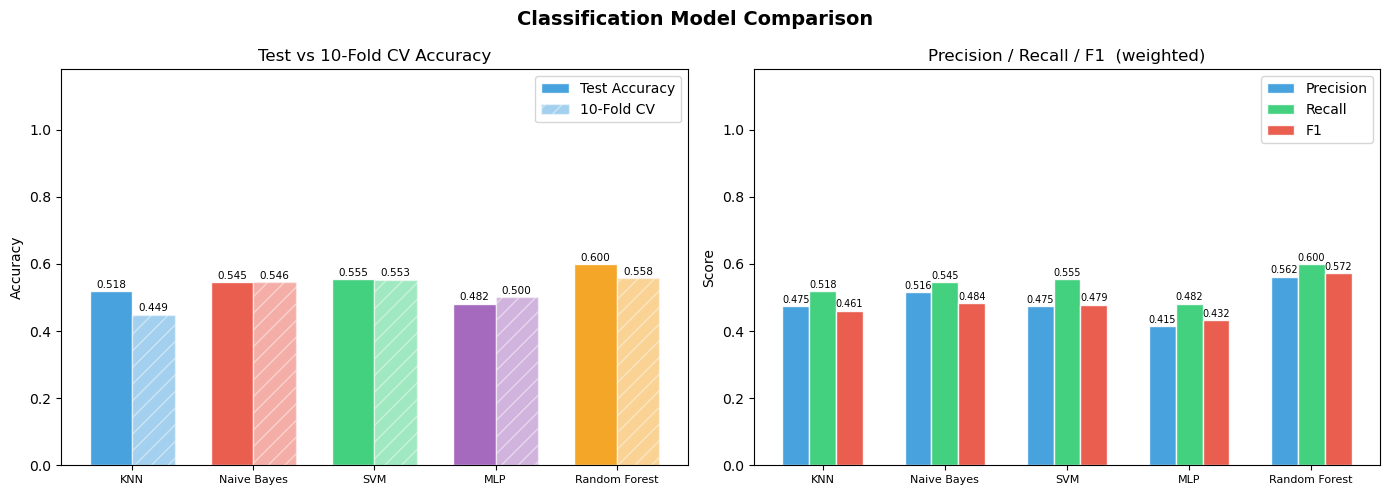

Saved: data/model_comparison.png


In [5]:
# MODEL COMPARISON CHART
test_accs  = [results[a]['accuracy']    for a in algo_names]
cv_accs    = [results[a]['cv_accuracy'] for a in algo_names]
f1_scores  = [results[a]['f1']         for a in algo_names]
precisions = [results[a]['precision']  for a in algo_names]
recalls    = [results[a]['recall']     for a in algo_names]
clrs = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Classification Model Comparison", fontsize=14, fontweight='bold')

# Test vs CV accuracy
x, w = np.arange(len(algo_names)), 0.35
b1 = axes[0].bar(x - w/2, test_accs, w, label='Test Accuracy', color=clrs,
                 alpha=0.9, edgecolor='white')
b2 = axes[0].bar(x + w/2, cv_accs,   w, label='10-Fold CV',    color=clrs,
                 alpha=0.45, edgecolor='white', hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(algo_names, fontsize=8)
axes[0].set_ylim(0, 1.18)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test vs 10-Fold CV Accuracy")
axes[0].legend()
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha='center', fontsize=7.5)

# F1 / Precision / Recall
x2, w2 = np.arange(len(algo_names)), 0.22
c0 = axes[1].bar(x2 - w2, precisions, w2, label='Precision', color='#3498DB',
                 alpha=0.9, edgecolor='white')
c1 = axes[1].bar(x2,      recalls,    w2, label='Recall',    color='#2ECC71',
                 alpha=0.9, edgecolor='white')
c2 = axes[1].bar(x2 + w2, f1_scores,  w2, label='F1',        color='#E74C3C',
                 alpha=0.9, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(algo_names, fontsize=8)
axes[1].set_ylim(0, 1.18)
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1  (weighted)")
axes[1].legend()
for container in [c0, c1, c2]:
    for b in container:
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                     f"{b.get_height():.3f}", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("data/model_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/model_comparison.png")


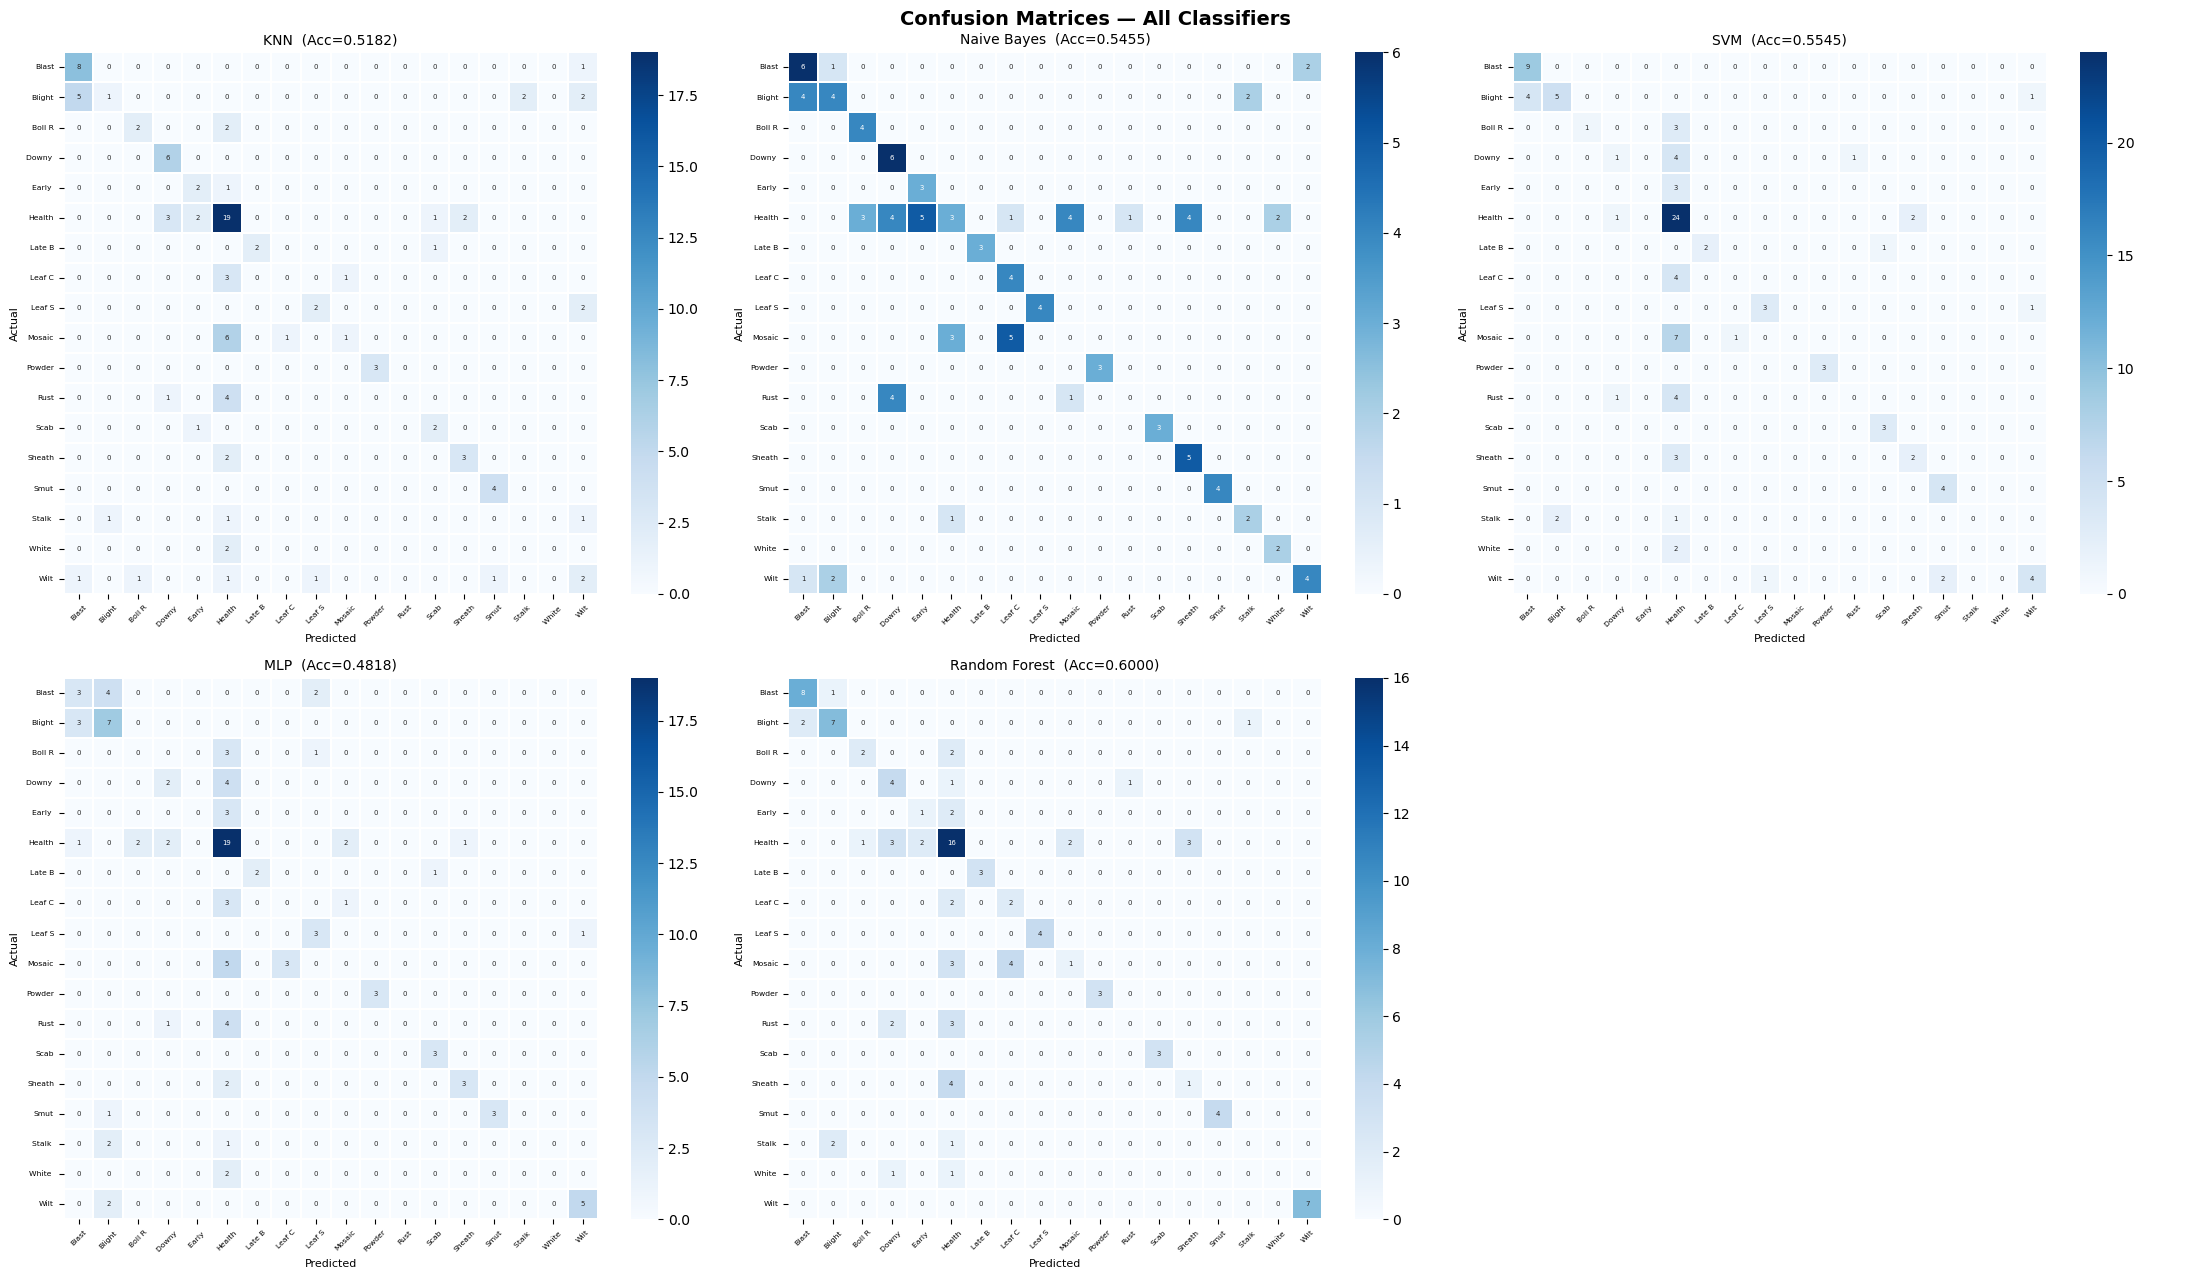

Saved: data/confusion_matrices.png


In [6]:
# CONFUSION MATRICES

short_names = [n[:6] for n in class_names]   # truncate for axis legibility

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, name in enumerate(algo_names):
    cm = confusion_matrix(y_test, results[name]['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.2, annot_kws={"size": 5})
    axes[i].set_title(f"{name}  (Acc={results[name]['accuracy']:.4f})", fontsize=10)
    axes[i].set_xlabel("Predicted", fontsize=8)
    axes[i].set_ylabel("Actual", fontsize=8)
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=5.5)
    axes[i].tick_params(axis='y', labelrotation=0,  labelsize=5.5)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("data/confusion_matrices.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/confusion_matrices.png")


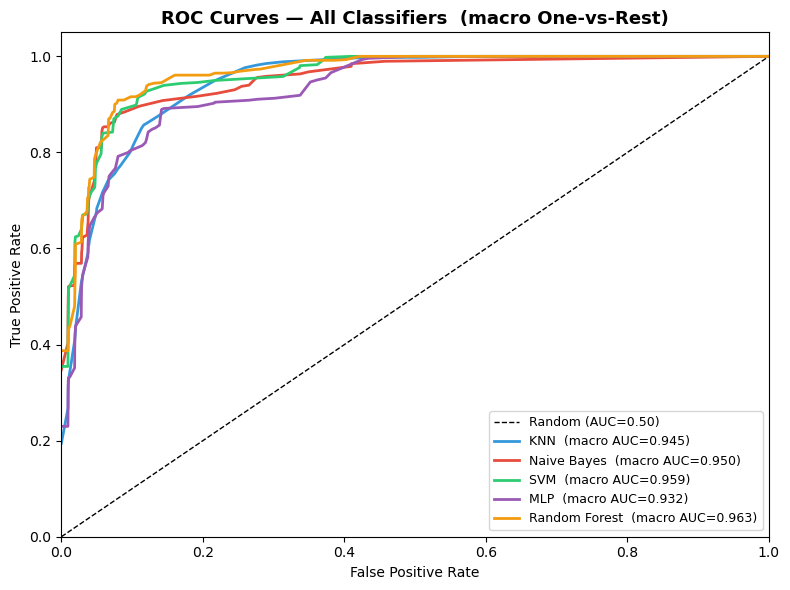

Saved: data/roc_curves.png


In [17]:
# ROC CURVES

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')

for name, clr in zip(algo_names, clrs):
    proba = results[name]['proba']   
    # Compute macro-average ROC
    all_fpr = np.unique(np.concatenate(
        [roc_curve(y_test_bin[:, c], proba[:, c])[0] for c in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve(y_test_bin[:, c], proba[:, c])
        mean_tpr += np.interp(all_fpr, fpr_c, tpr_c)
    mean_tpr /= n_classes
    roc_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, linewidth=2, color=clr,
            label=f"{name}  (macro AUC={roc_auc:.3f})")

ax.set_title("ROC Curves — All Classifiers  (macro One-vs-Rest)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("data/roc_curves.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved: data/roc_curves.png")


## Step 4 — Random Forest: Final Prediction Model

Random Forest is selected as the final prediction model.
Reason: Ensemble of decision trees — reduces overfitting,
        handles mixed feature types, provides feature importance.

Top 10 Most Important Features:
            Feature  Importance
   disease_severity    0.155305
          crop_type    0.099614
          potassium    0.094875
           nitrogen    0.085943
        temperature    0.085143
           rainfall    0.084676
heat_humidity_index    0.081520
           humidity    0.072944
         phosphorus    0.072081
            soil_ph    0.071614


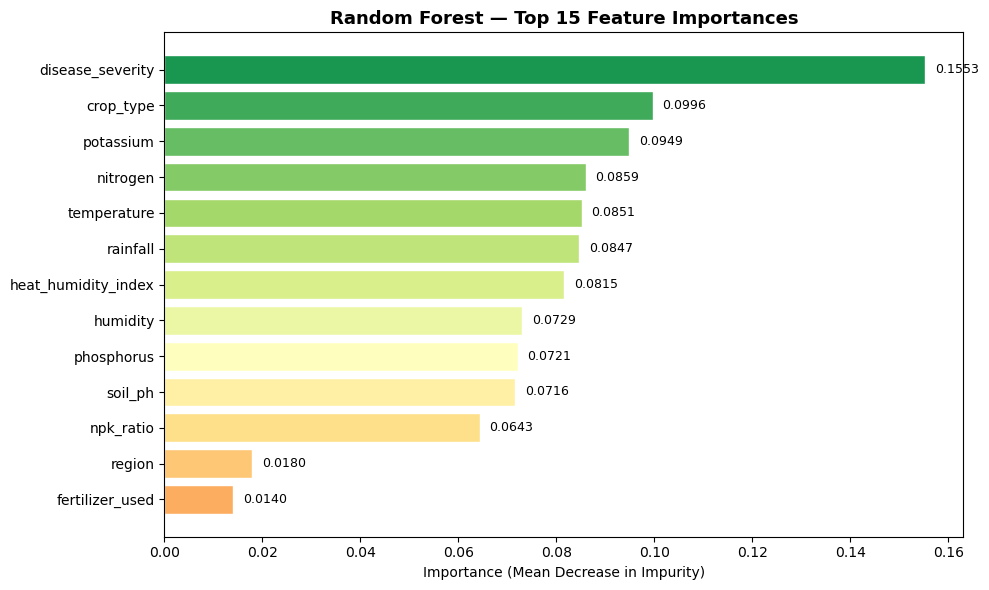


Saved: data/feature_importance.png
Saved: data/best_classifier.pkl


In [8]:
# RANDOM FOREST — FINAL PREDICTION MODEL
print("Random Forest is selected as the final prediction model.")
print("Reason: Ensemble of decision trees — reduces overfitting,")
print("handles mixed feature types, provides feature importance.\n")

rf = results['Random Forest']['clf']

# Feature importance
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(fi_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top15  = fi_df.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))
bars   = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1],
                 color=colors, edgecolor='white')
for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9)
ax.set_title("Random Forest — Top 15 Feature Importances",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
plt.tight_layout()
plt.savefig("data/feature_importance.png", dpi=130, bbox_inches='tight')
plt.show()
print("\nSaved: data/feature_importance.png")

# Save best model
import pickle
with open('data/best_classifier.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("Saved: data/best_classifier.pkl")


In [9]:
# RANDOM FOREST — TEST WITH SAMPLE CROP PROFILES
print("Testing 7 crop profiles (varied diseases and healthy):\n")

full_df_raw = pd.read_csv("data/cleaned_data.csv")

# Compute per-class mean profiles
disease_means = full_df_raw.groupby('disease_label')[feature_cols].mean()

def make_profile(class_id, **overrides):
    row = disease_means.loc[class_id].copy()
    for k, v in overrides.items():
        row[k] = v
    return row

# Get class IDs for a few representative diseases + healthy
le_disease = label_encoders['disease_label']
healthy_id    = le_disease.transform(['Healthy'])[0]
blight_id     = le_disease.transform(['Blight'])[0]
rust_id       = le_disease.transform(['Rust'])[0]
wilt_id       = le_disease.transform(['Wilt'])[0]
leaf_spot_id  = le_disease.transform(['Leaf Spot'])[0]
blast_id      = le_disease.transform(['Blast'])[0]
mildew_id     = le_disease.transform(['Powdery Mildew'])[0]

le_crop = label_encoders['crop_type']
le_reg  = label_encoders['region']

test_profiles = [
    ("Profile 1 — Healthy Rice (Terai)",
     make_profile(healthy_id,
                  crop_type=le_crop.transform(['Rice'])[0],
                  region=le_reg.transform(['Terai'])[0],
                  humidity=80.0, temperature=34.0, rainfall=220.0)),

    ("Profile 2 — Blight (high humidity)",
     make_profile(blight_id,
                  humidity=90.0, temperature=28.0, rainfall=260.0)),

    ("Profile 3 — Rust (Wheat, Hilly)",
     make_profile(rust_id,
                  crop_type=le_crop.transform(['Wheat'])[0],
                  region=le_reg.transform(['Hilly'])[0],
                  temperature=18.0)),

    ("Profile 4 — Wilt (Cotton, dry)",
     make_profile(wilt_id,
                  crop_type=le_crop.transform(['Cotton'])[0],
                  humidity=45.0, rainfall=50.0)),

    ("Profile 5 — Leaf Spot (Maize)",
     make_profile(leaf_spot_id,
                  crop_type=le_crop.transform(['Maize'])[0])),

    ("Profile 6 — Blast (Rice, Mountain)",
     make_profile(blast_id,
                  crop_type=le_crop.transform(['Rice'])[0],
                  region=le_reg.transform(['Mountain'])[0],
                  temperature=15.0, humidity=55.0)),

    ("Profile 7 — Powdery Mildew (Mustard)",
     make_profile(mildew_id,
                  crop_type=le_crop.transform(['Mustard'])[0])),
]

X_new = np.array([[p[f] for f in feature_cols] for _, p in test_profiles])

print(f"{'Profile':<42} {'RF Prediction':>20} {'Confidence':>12}")
print("-" * 78)
for i, (label, _) in enumerate(test_profiles):
    pred      = rf.predict(X_new[i:i+1])[0]
    proba_row = rf.predict_proba(X_new[i:i+1])[0]
    disease   = le_disease.inverse_transform([pred])[0]
    conf      = max(proba_row) * 100
    print(f"{label:<42} {disease:>20} {conf:>11.1f}%")


Testing 7 crop profiles (varied diseases and healthy):

Profile                                           RF Prediction   Confidence
------------------------------------------------------------------------------
Profile 1 — Healthy Rice (Terai)                        Healthy        34.0%
Profile 2 — Blight (high humidity)                        Blast        52.0%
Profile 3 — Rust (Wheat, Hilly)                         Healthy        45.0%
Profile 4 — Wilt (Cotton, dry)                            Blast        41.0%
Profile 5 — Leaf Spot (Maize)                         Leaf Spot        25.0%
Profile 6 — Blast (Rice, Mountain)                        Blast        46.0%
Profile 7 — Powdery Mildew (Mustard)             Powdery Mildew        76.0%


In [10]:
# INTERACTIVE CROP DISEASE PREDICTOR WIDGET
knn_clf = results['KNN']['clf']
nb_clf  = results['Naive Bayes']['clf']
svm_clf = results['SVM']['clf']
mlp_clf = results['MLP']['clf']
rf_clf  = results['Random Forest']['clf']

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

style  = {'description_width': '180px'}
layout = widgets.Layout(width='440px')

# Dropdown options derived from the actual encoded values
crop_options = [(c, i) for i, c in enumerate(label_encoders['crop_type'].classes_)]
reg_options  = [(r, i) for i, r in enumerate(label_encoders['region'].classes_)]
sev_options  = [(s, i) for i, s in enumerate(label_encoders['disease_severity'].classes_)]

w_crop   = widgets.Dropdown(options=crop_options, value=0,
                            description='Crop Type', style=style, layout=layout)
w_region = widgets.Dropdown(options=reg_options,  value=0,
                            description='Region',    style=style, layout=layout)
w_fert   = widgets.ToggleButtons(options=[('Yes', 1), ('No', 0)], value=1,
                                 description='Fertilizer Used', style=style)
w_sev    = widgets.Dropdown(options=sev_options, value=0,
                             description='Disease Severity', style=style, layout=layout)
w_ph     = widgets.FloatSlider(value=6.5,  min=4.5,  max=8.5, step=0.1,
                               description='Soil pH', style=style, layout=layout)
w_n      = widgets.IntSlider(value=90,  min=10,  max=160,
                              description='Nitrogen',    style=style, layout=layout)
w_p      = widgets.IntSlider(value=50,  min=15,  max=95,
                              description='Phosphorus',  style=style, layout=layout)
w_k      = widgets.IntSlider(value=50,  min=15,  max=95,
                              description='Potassium',   style=style, layout=layout)
w_temp   = widgets.FloatSlider(value=25.0, min=10.0, max=40.0, step=0.5,
                                description='Temperature (°C)', style=style, layout=layout)
w_hum    = widgets.FloatSlider(value=65.0, min=40.0, max=95.0, step=0.5,
                                description='Humidity (%)', style=style, layout=layout)
w_rain   = widgets.FloatSlider(value=110.0, min=30.0, max=285.0, step=1.0,
                                description='Rainfall (mm)', style=style, layout=layout)

btn = widgets.Button(description='  Predict Disease', button_style='info',
                     layout=widgets.Layout(width='180px', height='38px'))
out = widgets.Output()

display(HTML("<div style='font-family:sans-serif;font-size:15px;"
             "font-weight:bold;margin-bottom:10px'>🌾 Crop Disease Predictor</div>"))
display(widgets.VBox([
    w_crop, w_region, w_fert, w_sev,
    w_ph, w_n, w_p, w_k, w_temp, w_hum, w_rain,
    widgets.HBox([btn]), out
]))

def on_predict(b):
    with out:
        clear_output(wait=True)

        # Build the feature vector in the exact same order as training
        full_df_raw = pd.read_csv("data/cleaned_data.csv")

        # Compute npk_ratio and heat_humidity_index from widget inputs
        npk   = w_n.value / (w_p.value + w_k.value + 1)
        hhi   = (w_temp.value * w_hum.value) / 100

        feature_map = {
            'crop_type'          : w_crop.value,
            'region'             : w_region.value,
            'disease_severity'   : w_sev.value,
            'fertilizer_used'    : w_fert.value,
            'soil_ph'            : w_ph.value,
            'nitrogen'           : w_n.value,
            'phosphorus'         : w_p.value,
            'potassium'          : w_k.value,
            'temperature'        : w_temp.value,
            'humidity'           : w_hum.value,
            'rainfall'           : w_rain.value,
            'npk_ratio'          : npk,
            'heat_humidity_index': hhi,
        }

        x = np.array([[feature_map[f] for f in feature_cols]])

        clfs_all = [
            ('KNN',          knn_clf),
            ('Naive Bayes',  nb_clf),
            ('SVM',          svm_clf),
            ('MLP',          mlp_clf),
            ('Random Forest', rf_clf),
        ]

        disease_clr = {
            'Healthy'       : '#2ECC71',
            'Blast'         : '#E74C3C', 'Blight'       : '#E74C3C',
            'Late Blight'   : '#E74C3C', 'Early Blight' : '#C0392B',
            'Rust'          : '#E67E22', 'Wilt'          : '#E67E22',
            'Leaf Curl'     : '#F39C12', 'Leaf Spot'    : '#F39C12',
            'Stalk Rot'     : '#D35400', 'Sheath Rot'   : '#D35400',
            'Downy Mildew'  : '#8E44AD', 'Powdery Mildew':'#8E44AD',
            'Mosaic'        : '#2980B9', 'Smut'          : '#2980B9',
            'Scab'          : '#16A085', 'Boll Rot'      : '#16A085',
            'White Rust'    : '#1ABC9C',
        }

        rows       = ""
        vote_counts = {}

        for name, clf in clfs_all:
            pred      = clf.predict(x)[0]
            proba_row = clf.predict_proba(x)[0]
            disease   = label_encoders['disease_label'].inverse_transform([pred])[0]
            conf      = max(proba_row) * 100
            clr       = disease_clr.get(disease, '#7F8C8D')
            bw        = int(conf)
            vote_counts[disease] = vote_counts.get(disease, 0) + 1
            rows += (
                f"<tr>"
                f"<td style='padding:7px 12px;font-size:13px'>{name}</td>"
                f"<td style='padding:7px 12px'>"
                f"<span style='background:{clr}22;color:{clr};border:1px solid {clr};"
                f"border-radius:4px;padding:2px 10px;font-weight:bold;font-size:12px'>"
                f"{disease}</span></td>"
                f"<td style='padding:7px 12px'>"
                f"<div style='display:flex;align-items:center;gap:8px'>"
                f"<div style='width:100px;height:6px;background:#e8e8e8;border-radius:3px'>"
                f"<div style='width:{bw}%;height:100%;background:{clr};border-radius:3px'>"
                f"</div></div>"
                f"<span style='font-size:12px;color:#666'>{conf:.1f}%</span>"
                f"</div></td></tr>"
            )

        # Verdict = majority disease across all 5 models
        majority_disease = max(vote_counts, key=vote_counts.get)
        majority_votes   = vote_counts[majority_disease]
        vc               = disease_clr.get(majority_disease, '#7F8C8D')

        if majority_disease == 'Healthy':
            verdict = "CROP IS HEALTHY"
        elif majority_votes >= 4:
            verdict = f"HIGH RISK: {majority_disease.upper()}"
        elif majority_votes >= 3:
            verdict = f"LIKELY: {majority_disease.upper()}"
        else:
            verdict = f"POSSIBLE: {majority_disease.upper()} (models disagree)"

        html_out = (
            "<div style='font-family:sans-serif;border:1px solid #e0e0e0;"
            "border-radius:8px;overflow:hidden;margin-top:8px'>"
            "<table style='width:100%;border-collapse:collapse'>"
            "<thead><tr style='background:#f8f8f8;border-bottom:1px solid #e0e0e0'>"
            "<th style='padding:8px 12px;text-align:left;font-size:12px;"
            "color:#888;font-weight:500'>Algorithm</th>"
            "<th style='padding:8px 12px;text-align:left;font-size:12px;"
            "color:#888;font-weight:500'>Predicted Disease</th>"
            "<th style='padding:8px 12px;text-align:left;font-size:12px;"
            "color:#888;font-weight:500'>Confidence</th>"
            "</tr></thead><tbody>" + rows + "</tbody></table>"
            "<div style='padding:10px 12px;border-top:1px solid #e0e0e0;"
            "display:flex;justify-content:space-between;align-items:center'>"
            "<span style='font-size:13px;color:#666'>Majority vote: "
            + majority_disease + " (" + str(majority_votes) + "/5 models)</span>"
            "<span style='font-weight:bold;font-size:14px;color:" + vc + "'>"
            + verdict + "</span></div></div>"
        )
        display(HTML(html_out))

btn.on_click(on_predict)
